In [2]:
# run_tests_extended.py
"""
Extended experiments with validation split to detect overfitting.
All data scaled to [0, 1].
"""

import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from quantum_lstm_collapsed_state import QuantumLSTM   

import yfinance as yf
import pandas as pd



def split_and_scale_all(series, seq_len, 
                    train_ratio=0.7,
                     val_ratio=0.1, 
                    feature_range=(0,1)):
    """
    Scale the entire series to feature_range, 
    build sequences from the scaled full series,
    then split the sequences into train/val/test. 
    Returns tensors and the fitted scaler.
    Note: fitting on the full series causes data leakage,
      but guarantees no out-of-range values.
    """
    series = np.asarray(series).flatten().astype(np.float64)
    total_len = len(series)
    if total_len <= seq_len + 1:
        raise ValueError("Series too short for the requested seq_len.")

    # 1) Fit scaler on the entire series (change to training-only fit to avoid leakage)
    scaler = MinMaxScaler(feature_range=feature_range)
    scaler.fit(series.reshape(-1, 1))
    scaled_full = scaler.transform(series.reshape(-1, 1)).flatten()

    # 2) Build sequences from the scaled full series
    X_all = []
    y_all = []
    for i in range(0, len(scaled_full) - seq_len):
        X_all.append(scaled_full[i : i + seq_len])
        y_all.append(scaled_full[i + seq_len])
    X_all = np.array(X_all)   # shape (N_samples, seq_len)
    y_all = np.array(y_all).reshape(-1, 1)  # shape (N_samples, 1)

    # 3) Split sequences (indices refer to sequence samples, not raw time indices)
    n_samples = X_all.shape[0]
    train_end = int(train_ratio * n_samples)
    val_end = int((train_ratio + val_ratio) * n_samples)

    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_val   = X_all[train_end:val_end]
    y_val   = y_all[train_end:val_end]
    X_test  = X_all[val_end:]
    y_test  = y_all[val_end:]

    # 4) Sanity checks
    if X_train.size == 0 or X_val.size == 0 or X_test.size == 0:
        raise ValueError(
            f"Empty split: sizes -> train:{X_train.shape[0]}, val:{X_val.shape[0]}, test:{X_test.shape[0]}. "
            "Reduce seq_len or adjust split ratios or increase data length."
        )

    # 5) Convert to torch tensors with final shapes (samples, seq_len, 1) and (samples, 1)
    X_train = torch.tensor(X_train, dtype=torch.float64).unsqueeze(-1)
    y_train = torch.tensor(y_train, dtype=torch.float64)
    X_val   = torch.tensor(X_val,   dtype=torch.float64).unsqueeze(-1)
    y_val   = torch.tensor(y_val,   dtype=torch.float64)
    X_test  = torch.tensor(X_test,  dtype=torch.float64).unsqueeze(-1)
    y_test  = torch.tensor(y_test,  dtype=torch.float64)

    # 6) Quick prints for debugging
    print("Samples (seqs):", n_samples)
    print("Shapes -> X_train, y_train:", X_train.shape, y_train.shape)
    print("Ranges -> y_train min/max:", float(y_train.min()), float(y_train.max()))
    print("Ranges -> y_val   min/max:", float(y_val.min()), float(y_val.max()))
    print("Ranges -> y_test  min/max:", float(y_test.min()), float(y_test.max()))

    return X_train, y_train, X_val, y_val, X_test, y_test


def split_and_scale(series, seq_len, train_ratio=0.7, val_ratio=0.1):
    """
    Splits raw series into train/val/test, scales EACH split individually to [-1,1],
    then builds sequences. This avoids data leakage but means ranges differ per split.
    """
    total_len = len(series)
    train_end = int(train_ratio * total_len)
    val_end = int((train_ratio + val_ratio) * total_len)

    # 1. Split raw series first
    train_raw = series[:train_end].reshape(-1, 1).astype(np.float64)
    val_raw   = series[train_end:val_end].reshape(-1, 1).astype(np.float64)
    test_raw  = series[val_end:].reshape(-1, 1).astype(np.float64)

    # 2. Scale each split individually
    scaler_train = MinMaxScaler(feature_range=(-1, 1))
    train_scaled = scaler_train.fit_transform(train_raw).flatten()

    scaler_val = MinMaxScaler(feature_range=(-1, 1))
    val_scaled = scaler_val.fit_transform(val_raw).flatten()

    scaler_test = MinMaxScaler(feature_range=(-1, 1))
    test_scaled = scaler_test.fit_transform(test_raw).flatten()

    # 3. Build sequences
    def make_sequences(data):
        X, y = [], []
        for i in range(len(data) - seq_len):
            X.append(data[i:i+seq_len])
            y.append(data[i+seq_len])
        return np.array(X), np.array(y)

    X_train, y_train = make_sequences(train_scaled)
    X_val,   y_val   = make_sequences(val_scaled)
    X_test,  y_test  = make_sequences(test_scaled)

    # Reshape targets
    y_train = y_train.reshape(-1, 1)
    y_val   = y_val.reshape(-1, 1)
    y_test  = y_test.reshape(-1, 1)

    # Sanity check
    print("y_train range:", y_train.min(), y_train.max())
    print("y_val range:  ", y_val.min(), y_val.max())
    print("y_test range: ", y_test.min(), y_test.max())

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float64).unsqueeze(-1)
    y_train = torch.tensor(y_train, dtype=torch.float64)
    X_val   = torch.tensor(X_val,   dtype=torch.float64).unsqueeze(-1)
    y_val   = torch.tensor(y_val,   dtype=torch.float64)
    X_test  = torch.tensor(X_test,  dtype=torch.float64).unsqueeze(-1)
    y_test  = torch.tensor(y_test,  dtype=torch.float64)

    return X_train, y_train, X_val, y_val, X_test, y_test


def generate_sin_data(num_points=300, seq_len=10, noise_std=0.1,
                      train_ratio=0.7, val_ratio=0.1):
    x_vals = np.linspace(0, 8 * math.pi, num_points)
    y_vals = np.sin(x_vals) + noise_std * np.random.randn(num_points)
    return split_and_scale(y_vals, seq_len, train_ratio, val_ratio)


def generate_stock_data(ticker="GOOG", period="3y", seq_len=8,
                        train_ratio=0.7, val_ratio=0.1):
    df = yf.download(ticker, period=period)
    prices = df['Close'].values.astype(np.float64).flatten()
    return split_and_scale(prices, seq_len, train_ratio, val_ratio)


import os
import zipfile
import requests
import pandas as pd
import numpy as np
from io import BytesIO

# --------------------------------------------------------------------
# Configuration – adjust paths / filenames as needed
# --------------------------------------------------------------------
UCI_URL = "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip"
DATA_DIR = "data"
ZIP_NAME = "household_power_consumption.zip"
CSV_NAME = "household_power_consumption.txt"   # name inside the ZIP

# --------------------------------------------------------------------
def download_and_extract_zip(url, dest_dir, zip_name, csv_name):
    """
    Downloads a ZIP from `url`, extracts `csv_name` into `dest_dir`.
    Returns the full path to the extracted CSV file.
    """
    os.makedirs(dest_dir, exist_ok=True)
    zip_path = os.path.join(dest_dir, zip_name)
    csv_path = os.path.join(dest_dir, csv_name)

    # Download the ZIP file
    print(f"Downloading dataset from {url} ...")
    response = requests.get(url, stream=True, timeout=30)
    response.raise_for_status()  # Raise an error if download failed

    with open(zip_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

    # Extract only the required CSV file
    print(f"Extracting {csv_name} ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extract(csv_name, path=dest_dir)

    # Remove the ZIP after extraction to save space (optional)
    os.remove(zip_path)

    return csv_path

def generate_electricity_data(seq_len=10, train_ratio=0.7, val_ratio=0.1):
    """
    Returns train/val/test datasets from the UCI electricity consumption series.
    Caches the dataset in the 'data/' directory; downloads only if missing.
    Falls back to a synthetic AR(2) process if download fails.
    """
    csv_path = os.path.join(DATA_DIR, CSV_NAME)

    # -- 1. Try to read local CSV (cached) --
    if os.path.exists(csv_path):
        print(f"Found local file: {csv_path}")
        try:
            df = pd.read_csv(csv_path, sep=';', na_values='?', low_memory=False)
            power = df['Global_active_power'].dropna().values[:5000].astype(float)
        except Exception as e:
            print(f"Error reading cached CSV: {e}. Falling back to synthetic data.")
            power = None
    else:
        # -- 2. Download and extract if not cached --
        try:
            csv_path = download_and_extract_zip(UCI_URL, DATA_DIR, ZIP_NAME, CSV_NAME)
            df = pd.read_csv(csv_path, sep=';', na_values='?', low_memory=False)
            power = df['Global_active_power'].dropna().values[:5000].astype(float)
        except Exception as e:
            print(f"Download/extraction failed: {e}. Using synthetic AR(2) data.")
            power = None

    # -- 3. Fallback to synthetic data if anything above failed --
    if power is None:
        np.random.seed(42)
        ar = np.zeros(2000)
        ar[0] = 0.5
        ar[1] = 0.3
        for t in range(2, len(ar)):
            ar[t] = 0.6 * ar[t-1] - 0.3 * ar[t-2] + 0.1 * np.random.randn()
        power = ar
        print("Using synthetic AR(2) electricity data.")


    return split_and_scale(power, seq_len, train_ratio, val_ratio)

def generate_recent_weather_data(seq_len=10, num_days=360,train_ratio=0.7, val_ratio=0.1):
    """
    Retrieve recent weather data (e.g., last num_days days) for a selected region,
    create input sequences for forecasting, and split the data into training and test sets.

    Args:
        seq_len (int): Length of each sequence (number of time steps per sample).
        num_days (int): Number of past days to include. (Smaller num_days → fewer data points.)
        train_split (float): Fraction of data used for training.

    Returns:
        X_train (torch.Tensor): Training sequences with shape (samples, seq_len, 1).
        y_train (torch.Tensor): Training targets with shape (samples, 1).
        X_test (torch.Tensor): Test sequences.
        y_test (torch.Tensor): Test targets.
        scaler (MinMaxScaler): Scaler fitted to the temperature data (for inverse transformations).
    """
    from meteostat import Stations, Daily

    # Find weather stations in Istanbul (region code "34" in Turkey)
    from meteostat import Stations  # local import in case Meteostat isn't always used
    from datetime import datetime, timedelta
    stations = Stations()
    stations = stations.region("CA", "ON")  # Canada, Ontario region
    station_df = stations.fetch(1)  # Get one station
    if station_df.empty:
        raise ValueError("No station found for the specified region.")
    station_id = station_df.index[0]

    # Define the time period: get data for the past num_days
    end = datetime.now()
    start = end - timedelta(days=num_days)

    # Get daily data for the selected station
    data = Daily(station_id, start, end).fetch()
    data.reset_index(inplace=True)  # Make sure date is a column

    # Choose temperature metric: use 'tavg' if available, otherwise 'tmin'
    if "tavg" in data.columns and not data["tavg"].isnull().all():
        temps = data["tavg"]
    else:
        temps = data["tmin"]

    # Drop missing values and convert to a numpy array
    temps = temps.dropna().values.reshape(-1, 1)
    
    

    return split_and_scale(temps, seq_len, train_ratio, val_ratio)

# =============================================================================
# 2. Classical LSTM baseline (same as before)
# =============================================================================
class ClassicalLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=4, output_size=1, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), 4, dtype=x.dtype)
        c0 = torch.zeros(1, x.size(0), 4, dtype=x.dtype)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out


# =============================================================================
# 3. Training with validation
# =============================================================================
def train_with_validation(model, optimizer, loss_fn,
                          X_train, y_train, X_val, y_val,
                          num_epochs=200, batch_size=5, patience=20):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    wait = 0

    for epoch in range(num_epochs):
        # Training
        model.train()
        perm = torch.randperm(X_train.size(0))
        epoch_loss = 0.0
        for i in range(0, X_train.size(0), batch_size):
            idx = perm[i:i+batch_size]
            batch_x = X_train[idx]
            batch_y = y_train[idx]
            optimizer.zero_grad()
            pred = model(batch_x)
            loss = loss_fn(pred, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch_x.size(0)
        avg_train_loss = epoch_loss / X_train.size(0)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = loss_fn(val_pred, y_val).item()
        val_losses.append(val_loss)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        #     wait = 0
        # else:
        #     wait += 1
        #     if wait >= patience:
        #         print(f"Early stopping at epoch {epoch+1}")
        #         break

    # Restore best model
    model.load_state_dict(best_model_state)
    return train_losses, val_losses


def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        pred = model(X)
        mse = nn.MSELoss()(pred, y).item()
    return mse, pred.numpy().flatten(), y.numpy().flatten()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# =============================================================================
# 4. Experiment runner with validation and test
# =============================================================================

def run_experiment(dataset_name, data_generator, model_classes, model_names,
                   num_epochs=200, batch_size=5, lr=0.01, patience=50, **gen_kwargs):
    print(f"\n========== Running on {dataset_name} ==========")
    X_train, y_train, X_val, y_val, X_test, y_test = data_generator(**gen_kwargs)

    results = {}
    for key, model_class in model_classes.items():
        print(f"\n--- Training {model_names[key]} ---")
        model = model_class()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        train_losses, val_losses = train_with_validation(
            model, optimizer, loss_fn,
            X_train, y_train, X_val, y_val,
            num_epochs=num_epochs, batch_size=batch_size, patience=patience
        )
        # Evaluate on train, val, test (using best model already restored)
        train_mse, train_pred, train_true = evaluate_model(model, X_train, y_train)
        val_mse,   val_pred,   val_true   = evaluate_model(model, X_val,   y_val)
        test_mse,  test_pred,  test_true  = evaluate_model(model, X_test,  y_test)
        params = count_parameters(model)
        results[key] = {
            'train_mse': train_mse,
            'val_mse': val_mse,
            'test_mse': test_mse,
            'params': params,
            'train_predictions': train_pred,
            'train_true': train_true,
            'val_predictions': val_pred,
            'val_true': val_true,
            'test_predictions': test_pred,
            'test_true': test_true,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'model_name': model_names[key]   # store for plotting
        }
        print(f"{model_names[key]} - Train MSE: {train_mse:.6f}, Val MSE: {val_mse:.6f}, Test MSE: {test_mse:.6f}, Params: {params}")

    plot_loss_curves(dataset_name, results, model_names)
    plot_combined_predictions(dataset_name, results, model_names)   # new
    plot_predictions(dataset_name, results, model_names)   # keep or remove
    return results


def plot_all_predictions(dataset_name, results, model_names, max_samples=200):
    """
    Creates a figure with three rows (train, validation, test) and one column.
    Each row shows predictions vs true values for both models.
    """
    # For each dataset, we have results for both quantum and classical
    # We'll create a single figure per dataset
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    splits = [('train', 'Train set'), ('val', 'Validation set'), ('test', 'Test set')]

    for ax, (split, title) in zip(axes, splits):
        # Plot true values once (they are the same for both models)
        true_key = f'{split}_true'
        # Take the true values from the first model (should be identical copies)
        first_model = list(results.keys())[0]
        true = results[first_model][true_key][:max_samples]

        ax.plot(true, '-', label='True values', color='green', alpha=0.7, linewidth=2)

        # Plot predictions for each model
        colors = {'quantum': 'blue', 'classical': 'orange'}
        for key, name in model_names.items():
            pred = results[key][f'{split}_predictions'][:max_samples]
            ax.plot(pred, '--', label=f'{name} predictions', color=colors.get(key, 'gray'), linewidth=1.5)

        ax.set_title(f'{dataset_name} – {title}')
        ax.set_ylabel('Value (scaled)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Sample index')
    plt.tight_layout()
    plt.savefig(f'predictions_all_{dataset_name.replace(" ", "_")}.png', dpi=150)
    plt.show()

def plot_combined_predictions(dataset_name, results, model_names, max_points=500):
    """
    Create a single plot showing true values and predictions for train/val/test
    as a continuous sequence, with vertical lines separating the splits.
    """
    # We'll take the first model's true values (same for both)
    first_model = list(results.keys())[0]
    true_train = results[first_model]['train_true']
    true_val   = results[first_model]['val_true']
    true_test  = results[first_model]['test_true']

    # Concatenate true values
    true_all = np.concatenate([true_train, true_val, true_test])

    # For each model, concatenate predictions
    colors = {'quantum': 'blue', 'classical': 'orange'}
    fig, ax = plt.subplots(figsize=(14, 6))

    # Plot true values
    ax.plot(true_all, '-', label='True values', color='green', 
            alpha=0.8)

    # Plot each model's predictions
    for key, name in model_names.items():
        pred_train = results[key]['train_predictions']
        pred_val   = results[key]['val_predictions']
        pred_test  = results[key]['test_predictions']
        pred_all = np.concatenate([pred_train, pred_val, pred_test])
        ax.plot(pred_all, '--', label=f'{name} predictions', 
                color=colors.get(key, 'gray'), alpha=0.7)

    # Vertical lines to separate splits
    n_train = len(true_train)
    n_val   = len(true_val)
    ax.axvline(x=n_train, color='black', linestyle=':', label='Train/Val split')
    ax.axvline(x=n_train + n_val, color='black', linestyle=':', label='Val/Test split')

    ax.set_xlabel('Time step (concatenated)')
    ax.set_ylabel('Value (scaled to [-1,1])')
    ax.set_title(f'{dataset_name} – True vs Predictions (train/val/test continuous)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'combined_{dataset_name.replace(" ", "_")}.png', dpi=150)
    plt.show()


def plot_loss_curves(dataset_name, results, model_names):
    plt.figure(figsize=(12,5))
    for key, name in model_names.items():
        train_loss = results[key]['train_losses']
        val_loss = results[key]['val_losses']
        epochs = range(1, len(train_loss)+1)
        plt.plot(epochs, train_loss, '--', label=f'{name} (train)')
        plt.plot(epochs, val_loss, '-', label=f'{name} (val)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'{dataset_name} - Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'losses_{dataset_name.replace(" ", "_")}.png', dpi=150)
    plt.show()


def plot_predictions(dataset_name, results, model_names):
    plt.figure(figsize=(12,5))
    colors = {'quantum':'blue', 'classical':'orange'}
    # Plot true values once
    first_model = list(results.keys())[0]
    true  = results[first_model]['test_true']
    plt.plot(true, '-', label='True values', color='green', alpha=0.7)
    for key, name in model_names.items():
        pred  = results[key]['test_predictions']
        plt.plot(pred, '--', label=f'{name} predictions', color=colors.get(key, 'gray'))
    plt.xlabel('Sample index')
    plt.ylabel('Value (scaled to [-1, 1])')
    plt.title(f'{dataset_name} - Predictions vs True')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'predictions_{dataset_name.replace(" ", "_")}.png', dpi=150)
    plt.show()



========== Running on Weather ==========
y_train range: -1.0 1.0000000000000002
y_val range:   -1.0 0.7217391304347827
y_test range:  -0.6344827586206896 1.0

--- Training Quantum LSTM ---
Epoch  10 | Train Loss: 0.281473 | Val Loss: 0.335523
Epoch  20 | Train Loss: 0.112971 | Val Loss: 0.277376
Epoch  30 | Train Loss: 0.081753 | Val Loss: 0.185551
Epoch  40 | Train Loss: 0.076955 | Val Loss: 0.192552
Epoch  50 | Train Loss: 0.083116 | Val Loss: 0.226900
Epoch  60 | Train Loss: 0.062997 | Val Loss: 0.200637
Epoch  70 | Train Loss: 0.061079 | Val Loss: 0.179062
Epoch  80 | Train Loss: 0.059254 | Val Loss: 0.156750
Epoch  90 | Train Loss: 0.065097 | Val Loss: 0.135498
Epoch 100 | Train Loss: 0.071132 | Val Loss: 0.107716
Epoch 110 | Train Loss: 0.059363 | Val Loss: 0.087198
Epoch 120 | Train Loss: 0.064088 | Val Loss: 0.080388
Epoch 130 | Train Loss: 0.061225 | Val Loss: 0.128462
Epoch 140 | Train Loss: 0.068136 | Val Loss: 0.126696
Epoch 150 | Train Loss: 0.057500 | Val Loss: 0.120245


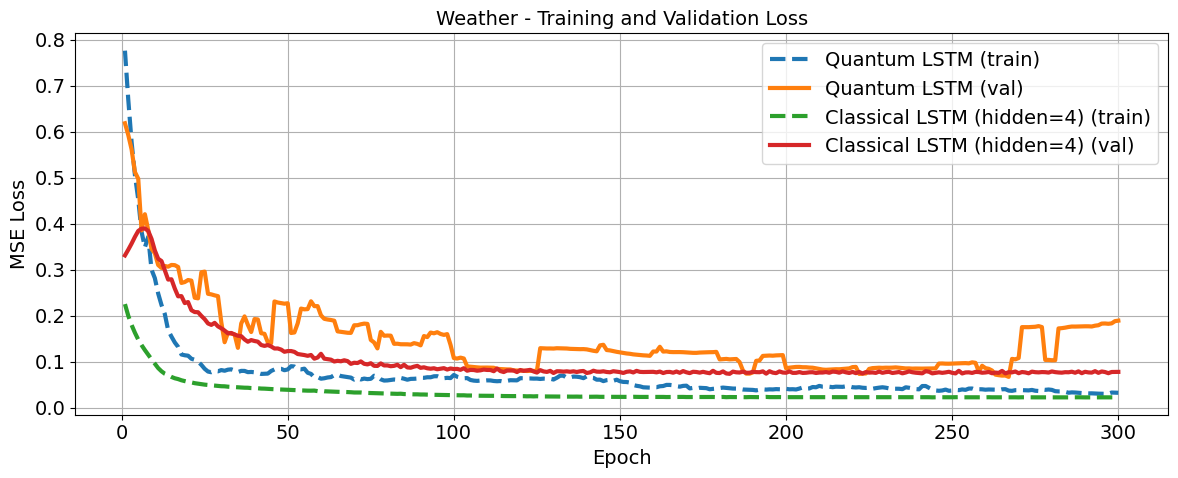

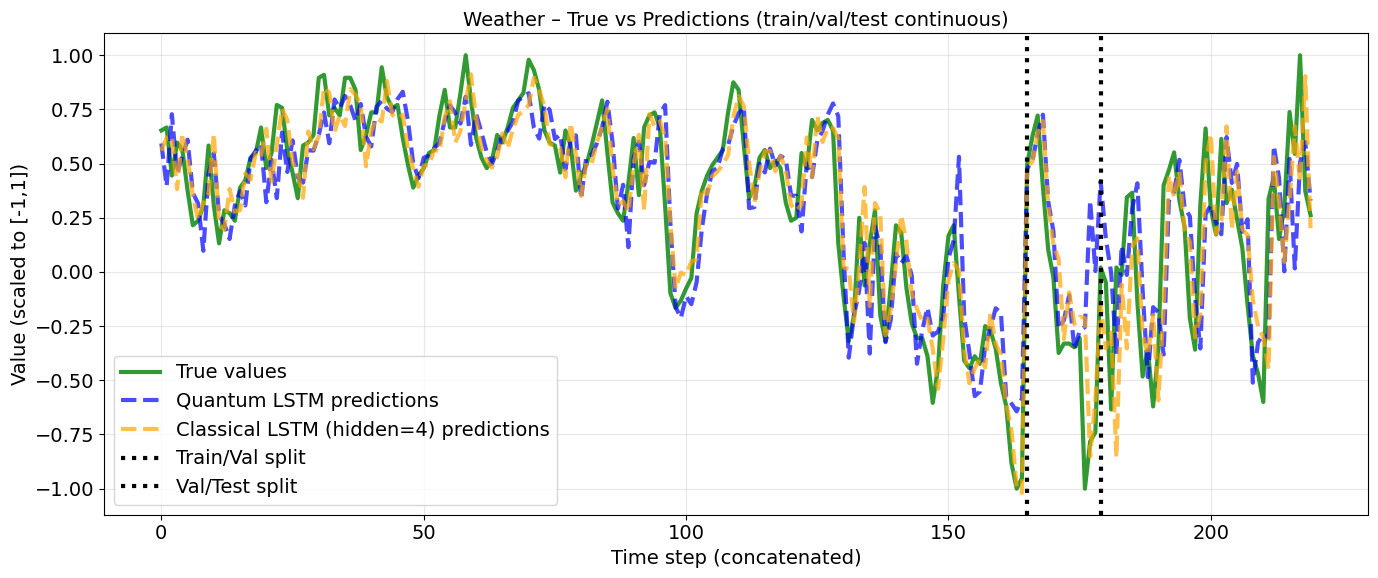

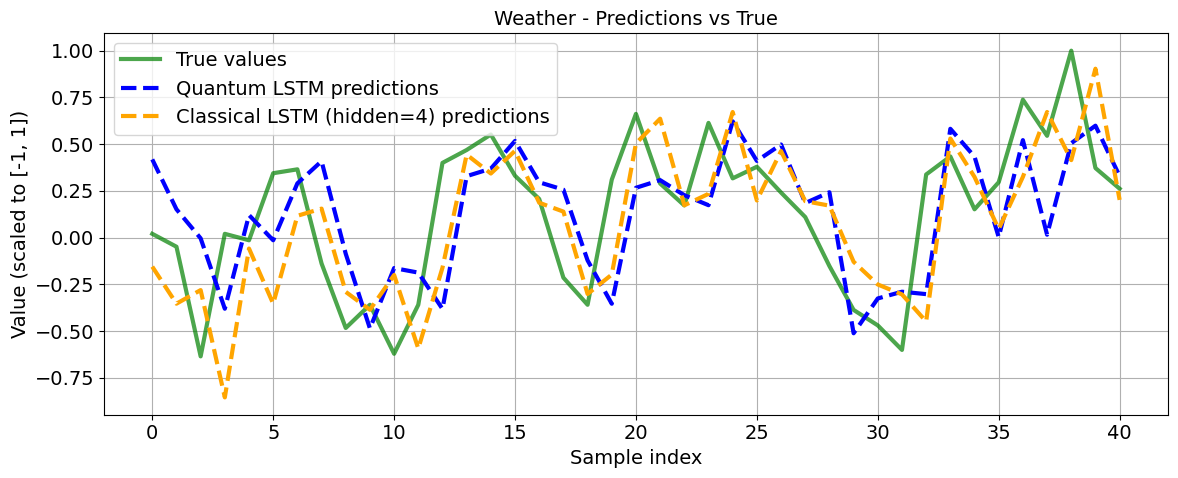


========== Running on Noisy Sine ==========
y_train range: -1.0 1.0
y_val range:   -0.3480209303602641 0.9999999999999997
y_test range:  -1.0 0.9761608041470131

--- Training Quantum LSTM ---
Epoch  10 | Train Loss: 0.330393 | Val Loss: 0.191492
Epoch  20 | Train Loss: 0.142189 | Val Loss: 0.178135
Epoch  30 | Train Loss: 0.081362 | Val Loss: 0.157816
Epoch  40 | Train Loss: 0.063760 | Val Loss: 0.103014
Epoch  50 | Train Loss: 0.048111 | Val Loss: 0.091560
Epoch  60 | Train Loss: 0.045546 | Val Loss: 0.085825
Epoch  70 | Train Loss: 0.040508 | Val Loss: 0.086980
Epoch  80 | Train Loss: 0.035911 | Val Loss: 0.076466
Epoch  90 | Train Loss: 0.035644 | Val Loss: 0.071760
Epoch 100 | Train Loss: 0.030620 | Val Loss: 0.081571
Epoch 110 | Train Loss: 0.033867 | Val Loss: 0.065801
Epoch 120 | Train Loss: 0.033679 | Val Loss: 0.071565
Epoch 130 | Train Loss: 0.024504 | Val Loss: 0.055457
Epoch 140 | Train Loss: 0.026065 | Val Loss: 0.088739
Epoch 150 | Train Loss: 0.029385 | Val Loss: 0.0880

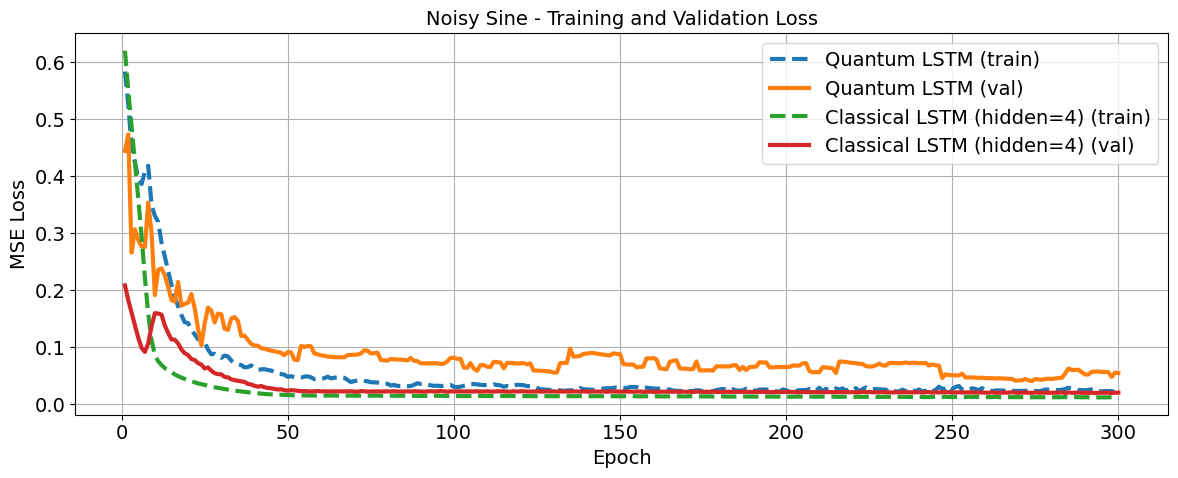

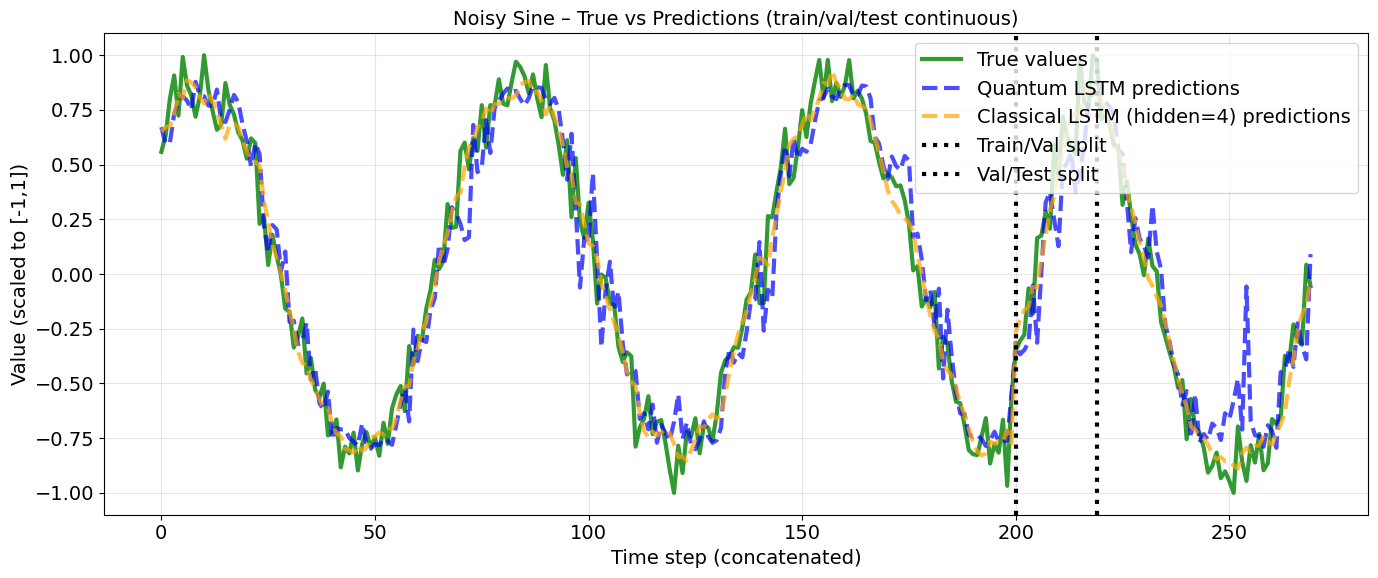

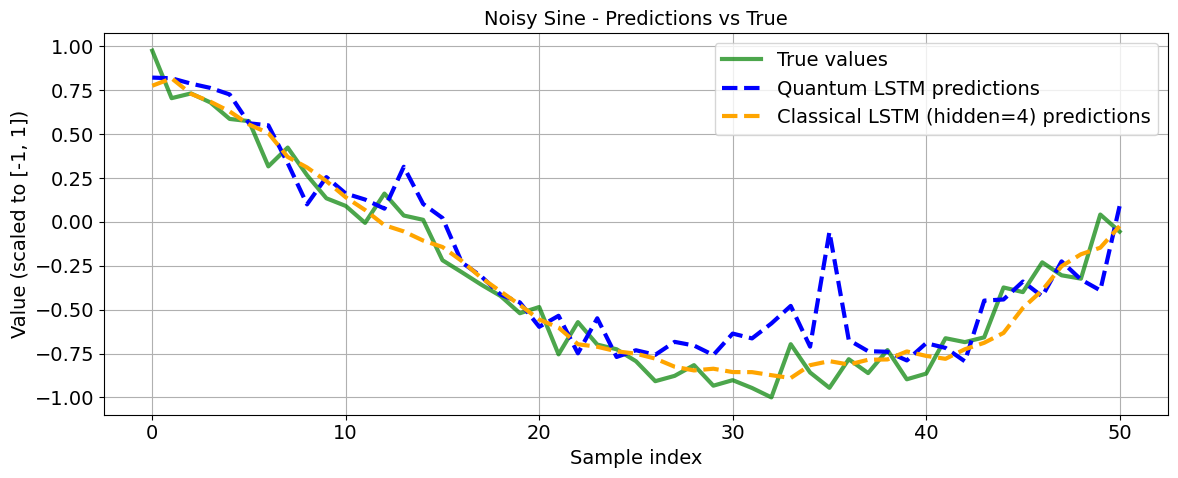


========== Running on Google Stock ==========


[*********************100%***********************]  1 of 1 completed


y_train range: -1.0 1.0
y_val range:   -0.7954349674240069 1.0
y_test range:  -0.8291090706182125 1.0

--- Training Quantum LSTM ---
Epoch  10 | Train Loss: 0.076189 | Val Loss: 0.264215
Epoch  20 | Train Loss: 0.040600 | Val Loss: 0.117372
Epoch  30 | Train Loss: 0.024234 | Val Loss: 0.059060
Epoch  40 | Train Loss: 0.016959 | Val Loss: 0.049002
Epoch  50 | Train Loss: 0.016644 | Val Loss: 0.041312
Epoch  60 | Train Loss: 0.014409 | Val Loss: 0.048947
Epoch  70 | Train Loss: 0.012621 | Val Loss: 0.083466
Epoch  80 | Train Loss: 0.012907 | Val Loss: 0.070502


KeyboardInterrupt: 

In [ ]:
# Explicitly use CPU
device = torch.device("cpu")
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "figure.titlesize": 14,
        "figure.figsize": (10, 5),
        "figure.dpi": 100,
        "savefig.dpi": 300,
        "lines.linewidth": 3,
        "lines.markersize": 6,
    }
)

model_classes = {'quantum': QuantumLSTM, 'classical': ClassicalLSTM}
model_names = {'quantum': 'Quantum LSTM', 'classical': 'Classical LSTM (hidden=4)'}
# Stock (Google)
# # Electricity
# run_experiment("Electricity", generate_electricity_data,
#                 model_classes, model_names,
#                 num_epochs=300, batch_size=10, lr=0.001,
#                 seq_len=10, train_ratio=0.7, val_ratio=0.1)

run_experiment("Weather", generate_recent_weather_data,
                model_classes, model_names,
                num_epochs=300, batch_size=10, lr=0.001,
                seq_len=10, train_ratio=0.7, val_ratio=0.1)
# Noisy sine
run_experiment("Noisy Sine", generate_sin_data, model_classes, model_names,
                num_epochs=300, batch_size=10, lr=0.001,
                num_points=300, seq_len=10, noise_std=0.1,
                train_ratio=0.7, val_ratio=0.1)






run_experiment("Google Stock", generate_stock_data, model_classes, model_names,
                num_epochs=300, batch_size=10, lr=0.001,
                ticker="GOOG", period="3y", seq_len=10,
                train_ratio=0.7, val_ratio=0.1)
print("\nAll experiments finished. Plots: losses_*.png and predictions_*.png")


========== Running on Electricity ==========
Found local file: data/household_power_consumption.txt
y_train range: -0.9999999999999999 1.0
y_val range:   -1.0 1.0000000000000002
y_test range:  -1.0 1.0

--- Training Quantum LSTM ---
Epoch  10 | Train Loss: 0.032595 | Val Loss: 0.074726
Epoch  20 | Train Loss: 0.025430 | Val Loss: 0.055919
Epoch  30 | Train Loss: 0.023919 | Val Loss: 0.057304
Epoch  40 | Train Loss: 0.021808 | Val Loss: 0.048453
Epoch  50 | Train Loss: 0.020625 | Val Loss: 0.048321
Epoch  60 | Train Loss: 0.020803 | Val Loss: 0.046783
Epoch  70 | Train Loss: 0.019832 | Val Loss: 0.046448
Epoch  80 | Train Loss: 0.019580 | Val Loss: 0.048625
Epoch  90 | Train Loss: 0.019431 | Val Loss: 0.048844
Epoch 100 | Train Loss: 0.019092 | Val Loss: 0.040850
Epoch 110 | Train Loss: 0.019151 | Val Loss: 0.043827
Epoch 120 | Train Loss: 0.019120 | Val Loss: 0.049642
Epoch 130 | Train Loss: 0.019203 | Val Loss: 0.043134
Epoch 140 | Train Loss: 0.019582 | Val Loss: 0.041902
Epoch 150 

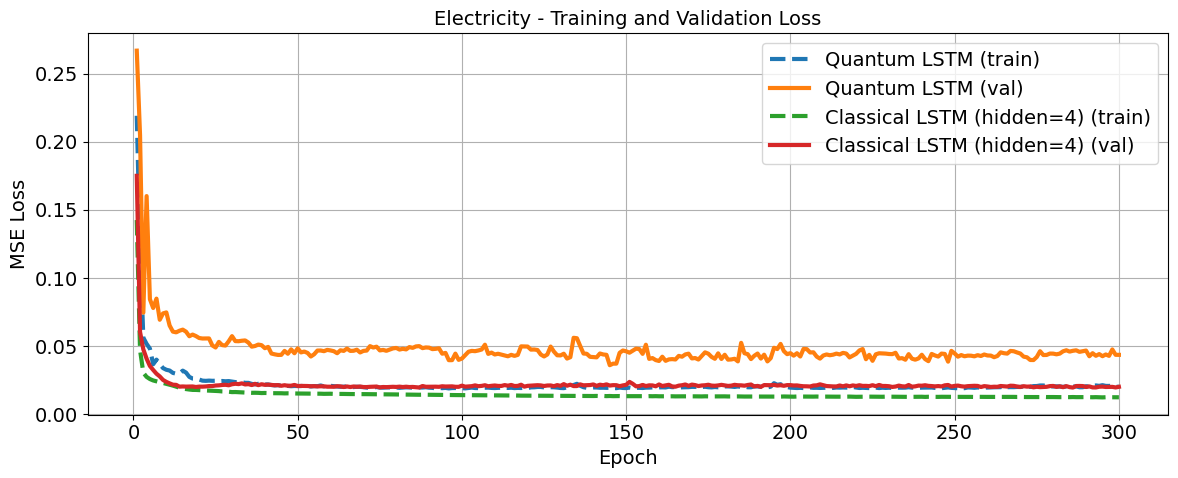

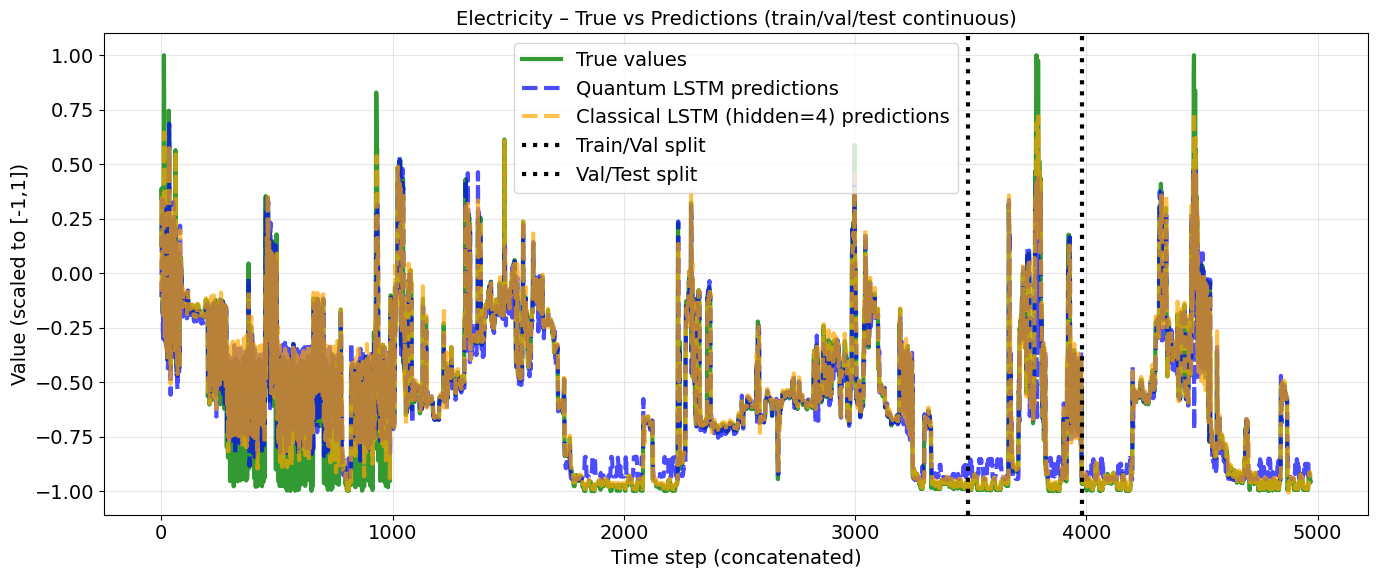

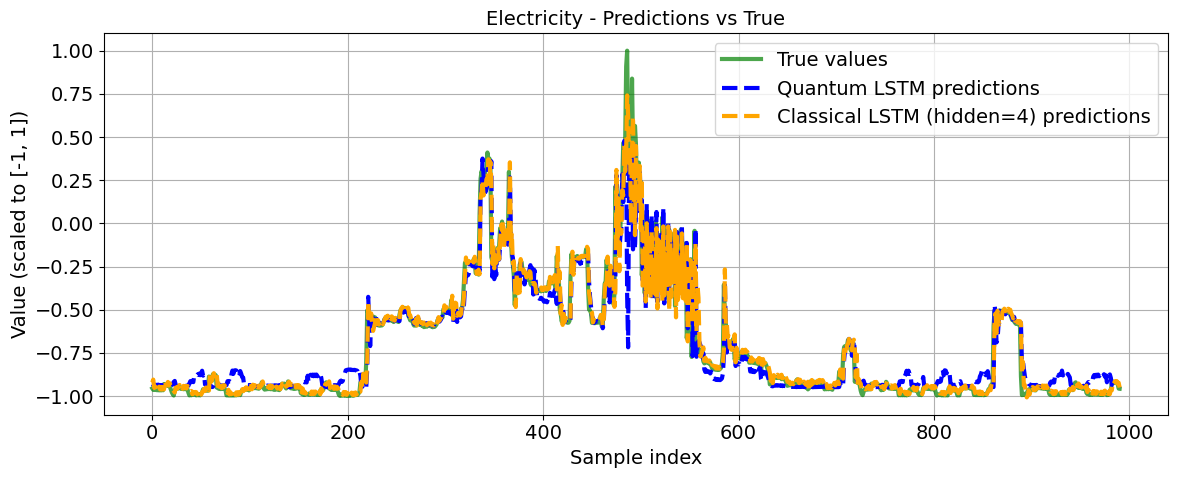

{'quantum': {'train_mse': 0.02003185604134261,
  'val_mse': 0.04355199157788362,
  'test_mse': 0.016278841504173625,
  'params': 36,
  'train_predictions': array([-0.1093743 ,  0.10055195,  0.21302263, ..., -0.9417784 ,
         -0.9392867 , -0.94113538], shape=(3490,)),
  'train_true': array([ 0.13166311,  0.38859275,  0.33848614, ..., -0.96162047,
         -0.95682303, -0.96215352], shape=(3490,)),
  'val_predictions': array([-0.91927662, -0.91542464, -0.9186662 , -0.87690599, -0.88310521,
         -0.87447383, -0.85378583, -0.8724874 , -0.85427113, -0.87141393,
         -0.87786682, -0.87117208, -0.85447062, -0.87141383, -0.87975881,
         -0.88985664, -0.93352281, -0.93090583, -0.9343229 , -0.93186186,
         -0.93448171, -0.94323554, -0.94472465, -0.94314963, -0.94674015,
         -0.94879385, -0.9489702 , -0.94877689, -0.94835613, -0.94606398,
         -0.94370305, -0.94520446, -0.94382859, -0.94511629, -0.94395224,
         -0.94512597, -0.94356093, -0.94291148, -0.93075441

In [4]:
device = torch.device("cpu")
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "figure.titlesize": 14,
        "figure.figsize": (10, 5),
        "figure.dpi": 100,
        "savefig.dpi": 300,
        "lines.linewidth": 3,
        "lines.markersize": 6,
    }
)

model_classes = {'quantum': QuantumLSTM, 'classical': ClassicalLSTM}
model_names = {'quantum': 'Quantum LSTM', 'classical': 'Classical LSTM (hidden=4)'}
# Stock (Google)
# Electricity
run_experiment("Electricity", generate_electricity_data,
                model_classes, model_names,
                num_epochs=300, batch_size=10, lr=0.001,
                seq_len=10, train_ratio=0.7, val_ratio=0.1)